In [1]:
import numpy as np
import pandas as pd

# Parse Ratings
df = pd.read_csv("./data/Music AI Eval Session 1_March 17, 2024_08.32.csv")
df.drop([0,1,3,10], axis=0, inplace=True) # Remove my test

song_id_list = ['03', '04', '05', '06', '07', '08', '10', '11', '12', '20']
q_id_list = []

for song_id in song_id_list:
    for i in range(3):
        col_name = f"Q {song_id}_{i}"
        q_id_list.append(col_name)
        # Cast ratings in str to int
        df[col_name] = pd.to_numeric(df[col_name])

# Remove redundant cols
new_df = df[['IPAddress'] + q_id_list]
new_df.reset_index(drop=True, inplace=True)

In [2]:
## Preprocessing
# Remove Runs with anchor < 4 (bad, poor, fair)
for i, row in new_df.iterrows():
    for song_id in song_id_list:
        tmp_list = [f"Q {song_id}_{j}" for j in range(3)]
        ratings = row[tmp_list].tolist()
        has_nan = [np.isnan(item) for item in ratings]

        # Remove incompelete runs
        if any(has_nan) and not all(has_nan):
            new_df.loc[i, tmp_list] = np.nan
            # print("nan", i, tmp_list)
        elif ratings[0] < 4:
            # print(i, tmp_list)
            new_df.loc[i, tmp_list] = np.nan

1 ['Q 05_0', 'Q 05_1', 'Q 05_2']
3 ['Q 04_0', 'Q 04_1', 'Q 04_2']
3 ['Q 05_0', 'Q 05_1', 'Q 05_2']
3 ['Q 06_0', 'Q 06_1', 'Q 06_2']
8 ['Q 07_0', 'Q 07_1', 'Q 07_2']
nan 8 ['Q 11_0', 'Q 11_1', 'Q 11_2']
8 ['Q 20_0', 'Q 20_1', 'Q 20_2']
nan 10 ['Q 10_0', 'Q 10_1', 'Q 10_2']
12 ['Q 04_0', 'Q 04_1', 'Q 04_2']
12 ['Q 08_0', 'Q 08_1', 'Q 08_2']
12 ['Q 11_0', 'Q 11_1', 'Q 11_2']


/Users/fengyuka/Documents/PhD/Research/magenta_env/lib/python3.8/site-packages/pandas/core/indexing.py:1817: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


In [7]:
# Count Ratings
cnt = 0
q_score = {}
for q_id in q_id_list:
    # q_score[q_id] = [score_map[i] for i in new_df[q_id] if i is not np.nan]
    tmp = [i for i in new_df[q_id] if not np.isnan(i)]
    q_score[q_id] = tmp
    cnt += len(tmp)
print(f"Rating Count: {cnt}")

Rating Count: 114


In [8]:
# Concat ratings for MT vs. MASS
model_score = {}
for i in range(3):
    model_score[i] = []
    for song_id in song_id_list:
        model_score[i] += q_score[f"Q {song_id}_{i}"]

In [10]:
# P-Value
from scipy.stats import wilcoxon
mt_vs_mass = wilcoxon(model_score[1], model_score[2], alternative='less', mode='approx')
print(mt_vs_mass)

WilcoxonResult(statistic=46.5, pvalue=0.0004053780153447902)


## Plot Result

In [11]:
avg_score = [np.mean(model_score[i]) for i in range(3)]
std_score = [np.std(model_score[i]) for i in range(3)]

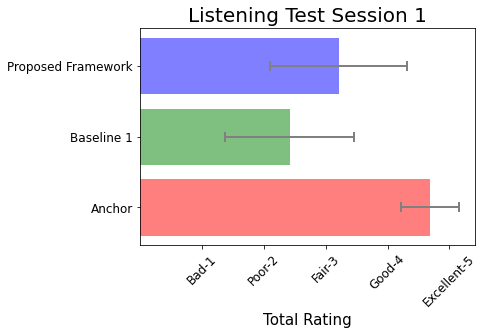

In [14]:
import matplotlib.pyplot as plt

plt.barh(['Anchor', 'Baseline 1', 'Proposed Framework'], 
        avg_score, xerr=std_score, alpha=0.5,
        color=['red', 'green', 'blue', 'magenta'],
        error_kw=dict(ecolor='gray', lw=2, capsize=5, capthick=2))
plt.yticks(fontsize=12)
plt.xticks([1,2,3,4,5], ['Bad-1', 'Poor-2', 'Fair-3', 'Good-4', 'Excellent-5'],rotation=45, fontsize=12)
plt.xlabel("Total Rating", fontsize = 15)
plt.title("Listening Test Session 1", fontsize=20)

plt.savefig('../manuscript/Figures/session 1.png', bbox_inches='tight', dpi=300)
plt.show()